In [33]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

In [34]:
!make clean
!make

rm -f test_performance_threadpool 
g++  -std=c++20 -pthread -Wall -I../../../../  test_performance_threadpool.cpp -o test_performance_threadpool


In [35]:
def run_test(test_name,n_runs = 200,n_elems = 16000,n_threads = 1):
    if not isinstance(n_elems,Iterable):
        n_elems = [n_elems]
    if not isinstance(n_threads, Iterable):
        n_threads = [n_threads]

    results = []
    for threads in n_threads:
        for elem in n_elems:
            !sh risultati.sh $test_name $n_runs $elem $threads
            results.append(np.genfromtxt(test_name + ".txt",delimiter=',',dtype=int)[:-1])

    return results

In [36]:
def multi_plot(data1, data2, title, labels):

    fig, ax = plt.subplots(figsize=[10, 10])

    boxes = []
    colors = []
    ticks = []

    for i in range(0,len(data1)):
        boxes.append(data1[i])
        boxes.append(data2[i])
        ticks.append(str(n_threads[i]))
        ticks.append(str(n_threads[i]))
        colors.append("peachpuff")
        colors.append("orange")

    bplot = ax.boxplot(boxes, showfliers=False, patch_artist=True)
    # Etichette per gli assi
    ax.set_xticks(range(1,1+len(boxes)),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)

    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    ax.legend([bplot["boxes"][0], bplot["boxes"][1]], [labels[0], labels[1]], loc='upper left')

    for median in bplot['medians']:
        median.set_color('red')

    plt.show()

In [47]:
def plot(data_list, title, labels):

    fig, ax = plt.subplots(figsize=[16, 8])

    boxes = []
    ticks = []

    for i in range(0,len(data_list)):
        boxes.append(data_list[i])
        ticks.append(labels[i])

    bplot = ax.boxplot(boxes, showfliers=False)
    # Etichette per gli assi
    ax.set_xticks(range(1,len(labels)+1),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)

    for median in bplot['medians']:
        median.set_color('red')

    plt.show()


# Set number of runs

In [38]:
n_runs = 10

# Set number of threads

In [45]:
n_threads = [1,2,4,6,8,10,12,14]

# Set number of elements

In [40]:
n_elems = 100000

# Set test name

In [41]:
test_name = "test_performance_threadpool"

# Run single-threaded test between all types of queues

In [46]:
test1 = run_test(test_name,n_runs,n_elems,n_threads[0])
test2 = run_test(test_name,n_runs,n_elems,n_threads[1])
test3 = run_test(test_name,n_runs,n_elems,n_threads[2])
test4 = run_test(test_name,n_runs,n_elems,n_threads[3])
test5 = run_test(test_name,n_runs,n_elems,n_threads[4])
test6 = run_test(test_name,n_runs,n_elems,n_threads[5])
test7 = run_test(test_name,n_runs,n_elems,n_threads[6])
test8 = run_test(test_name,n_runs,n_elems,n_threads[7])

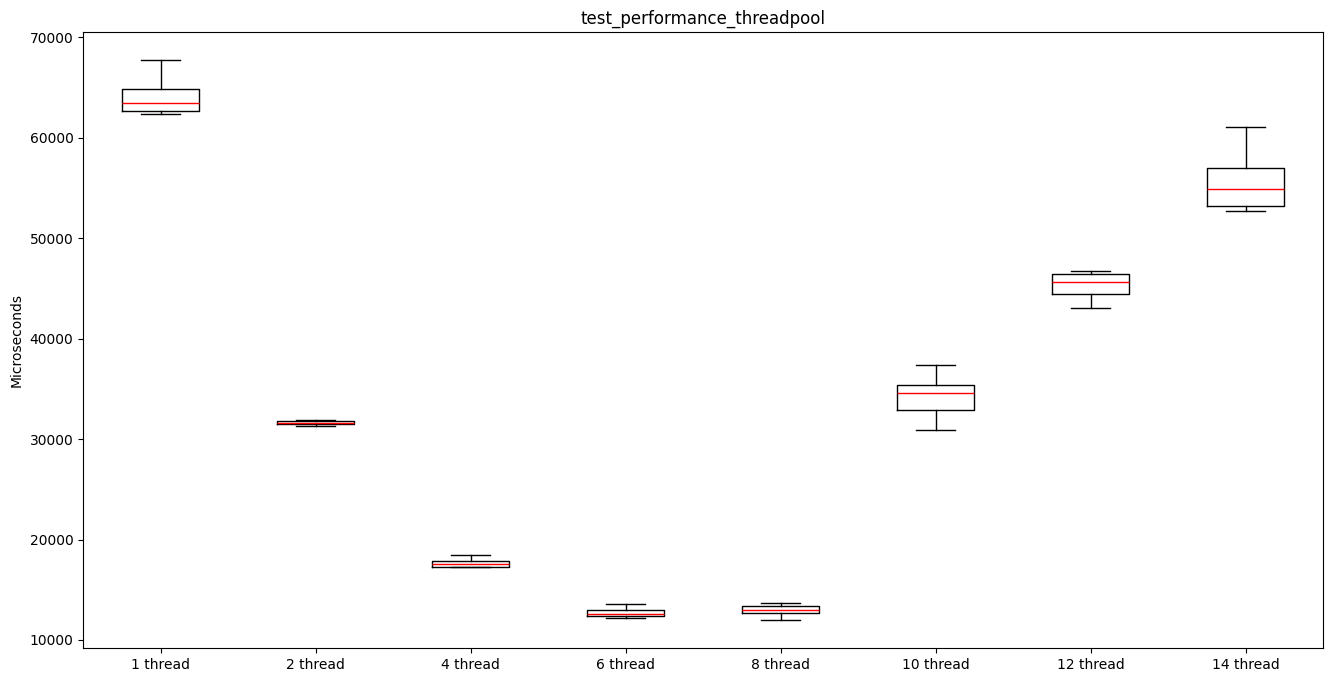

In [48]:
plot([test1[0],test2[0],test3[0],test4[0],test5[0],test6[0],test7[0],test8[0]],test_name,["1 thread","2 thread","4 thread","6 thread","8 thread","10 thread","12 thread","14 thread"])